## Import

In [ ]:
from pyhgf.model import Network
from scipy.stats import norm
import pandas as pd
import time
import numpy as np
from voting import generate_observations,generate_candidates,individual_vote
import altair as alt
import matplotlib.pyplot as plt
import colorsys
import altair as alt
import jax.numpy as jnp
import pandas as pd
import altair as alt
from scipy.stats import norm

# Import JAX and related modules
from jax import random, vmap
from jax.tree_util import Partial
from functools import partial as Partial

## Parameters

In [2]:
# Parameters for the simulation
n_candidates = 3
n_preferences = 3
n_agents = 100_000
voting_system = "basic" # "basic", "basic (ToM)", "ranked", "quadratic"

# Generate observations, tonic volatilities, candidate and mask
input_data = generate_observations(n_nodes=n_preferences, n_steps=500, scenario=1)
tonic_volatilities = np.random.normal(-3.0, 1.0, n_agents)
candidate_list = generate_candidates(n_candidates=n_candidates, n_preferences=n_preferences)
mask = np.ones(n_candidates)

## Agents

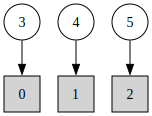

In [3]:
# Create agent preferences dynamically based on n_preferences
network = Network()

# Add binary-state nodes to the network
network.add_nodes(kind="binary-state", n_nodes=n_preferences)

# Add value nodes for each binary-state node
for i in range(n_preferences):
    network.add_nodes(value_children=i)

# Plot the network
network.plot_network()

## Round one

In [4]:
# Setup and vectorize the get_votes function for the first round
get_votes_fn = Partial(
    individual_vote,
    network=network,
    candidates=candidate_list,
    n_preferences=n_preferences,
    input_data=input_data,
    mask=mask,
    voting_system=voting_system
)
vmap_get_votes_fn = vmap(get_votes_fn)
key = random.PRNGKey(int(time.time()))
keys = random.split(key, n_agents)
votes, dissatisfactions = vmap_get_votes_fn(tonic_volatilities, keys)

In [ ]:
# Split into 10 simulations
sim_votes = np.array_split(votes, 100)
sim_diss = np.array_split(dissatisfactions, 100)  # ← nouveau : split par simulation

# Prepare a list to store proportions and dissatisfaction for each simulation
rows = []

for i, (vote_chunk, diss_chunk) in enumerate(zip(sim_votes, sim_diss)):
    total_votes = len(vote_chunk)
    unique, counts = np.unique(vote_chunk, return_counts=True)
    
    # Compute mean dissatisfaction per candidate for this simulation
    mean_diss = np.mean(diss_chunk, axis=0)  # shape = (n_candidates,)
    mean_diss = np.array(mean_diss, dtype=float)
    for candidate, count in zip(unique, counts):
        rows.append({
            'simulation_number': i + 1,  # simulation numbers 1–100
            'candidate': candidate,
            'proportion': count / total_votes,
            'mean_dissatisfaction': mean_diss[candidate]  # ← nouvelle colonne
        })

# Convert to DataFrame
df_simulations = pd.DataFrame(rows)

# Optional: convert candidate to categorical for Altair
df_simulations['candidate'] = df_simulations['candidate'].astype('category')
df_simulations['candidate_id'] = df_simulations['candidate'].cat.codes

df_simulations

,simulation_number,candidate,proportion,mean_dissatisfaction,candidate_id
0,1,0,0.031,-2.607153,0
1,1,1,0.808,-1.586916,1
2,1,2,0.161,-3.810955,2
3,2,0,0.023,-2.606800,0
4,2,1,0.788,-1.587328,1
...,...,...,...,...,...
295,99,1,0.797,-1.581974,1
296,99,2,0.164,-3.825540,2
297,100,0,0.032,-2.602889,0
298,100,1,0.816,-1.584036,1


In [ ]:
# define a global color scale for candidates
all_candidates = sorted(df_simulations['candidate_id'].unique())
color_scale = alt.Scale(domain=all_candidates, scheme='pastel1')


In [12]:
# Convertir en DataFrame
rows = []
x_min, x_max = -5, 9
x_vals = np.linspace(x_min, x_max, 300)

for i, (mus, sigmas) in enumerate(candidate_list):
    for pref in range(len(mus)):
        pdf = norm.pdf(x_vals, loc=mus[pref], scale=sigmas[pref])
        for x, y in zip(x_vals, pdf):
            rows.append({
                "candidate": f"C{i+1}",
                "preference": f"Preference {pref+1}",
                "x": x,
                "pdf": y
            })

df = pd.DataFrame(rows)

# Densités classiques (transparence)
chart = alt.Chart(df).mark_area(
    interpolate='monotone',
    fillOpacity=0.4,
).encode(
    x=alt.X('x:Q', title="Preference Value"),
    y=alt.Y('pdf:Q', title="Density"),
    color=alt.Color('candidate:N', title="Candidate")
).facet(
    row=alt.Row('preference:N')
).properties(
    title='Candidate Preference Distributions (Gaussian)'
)

chart


alt.FacetChart(...)

- panel B les résultats à deux tours, sans le reste

In [ ]:
# define a global color scale for candidates
all_candidates = sorted(df_simulations['candidate_id'].unique())
color_scale = alt.Scale(domain=all_candidates, scheme='pastel1')

# interactive selections
highlight = alt.selection_point(fields=['candidate_id'], on='mouseover', empty='all')
candidate_select = alt.selection_point(fields=['candidate_id'], bind='legend', empty='all')

# create a dummy column for the legend of simulations
df_simulations["unit"] = "— = one simulation"

# identify top 2 (or winners) for each simulation
top2_winners = (
    df_simulations
    .groupby("simulation_number", group_keys=False)
    .apply(lambda x: x.nlargest(2, "proportion"))  # top 2 par simulation
)

# create df_wins before the histogram
df_wins = (
    top2_winners.groupby("candidate_id")
    .agg(
        wins=("candidate_id", "count"),
        mean_dissatisfaction=("mean_dissatisfaction", "mean")
    )
    .reset_index()
)

# chart votes
votes_chart = (
    alt.Chart(df_simulations)
    .mark_area(opacity=0.85)
    .encode(
        x=alt.X('simulation_number:N', axis=alt.Axis(labels=False, ticks=False, title=None)),
        y=alt.Y('proportion:Q', stack='center', title='Vote Proportion', axis=alt.Axis(format='.0%')),
        color=alt.Color('candidate_id:N', scale=color_scale, legend=alt.Legend(title='Candidate')),
        opacity=alt.condition(candidate_select, alt.value(1), alt.value(0.2)),
        detail="unit",
        tooltip=[
            alt.Tooltip('candidate:N', title='Candidate'),
            alt.Tooltip('proportion:Q', title='Proportion', format='.1%'),
            alt.Tooltip('mean_dissatisfaction:Q', title='Mean Dissatisfaction', format='.2f'),
            alt.Tooltip('simulation_number:N', title='Simulation'),
            alt.Tooltip('unit:N', title='Unit')
        ]
    )
    .add_params(highlight, candidate_select)
    .properties(width=1000, height=400)
)

# create a dummy legend for "— = one simulation"
legend_dash = (
    alt.Chart(df_simulations)
    .mark_point(size=100, filled=True)
    .encode(
        color=alt.Color("unit:N", legend=alt.Legend(title="Notation"))
    )
    .properties(width=50, height=50)
)

# histogram of wins
hist = (
    alt.Chart(df_wins)
    .mark_bar()
    .encode(
        x=alt.X("candidate_id:N", title="Candidate", sort="-y"),
        y=alt.Y("wins:Q", title="Number of Times in Second Round"),
        color=alt.Color("candidate_id:N", scale=color_scale, legend=None),
        opacity=alt.condition(candidate_select, alt.value(1), alt.value(0.2)),
        tooltip=[
            alt.Tooltip("candidate_id:N", title="Candidate"),
            alt.Tooltip("wins:Q", title="Number of Times in Second Round"),
            alt.Tooltip("mean_dissatisfaction:Q", title="Mean Dissatisfaction", format=".2f")
        ]
    )
    .add_params(highlight, candidate_select)
    .properties(width=300, height=400)
)

# combine the charts
combined_chart = (
    (votes_chart | hist) & legend_dash
).properties(
    title=f"Simulation Results ({voting_system.capitalize()} Voting System)"
)

combined_chart


/var/folders/td/5r8mr8t14cn_c4w5c8ty48lw0000gn/T/ipykernel_23621/2996536470.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(2, "proportion"))  # top 2 par simulation


alt.VConcatChart(...)

# Round two

In [14]:
# For each simulation select the two best candidates
best_two_candidates = (
    df_simulations.groupby('simulation_number', group_keys=False)
    .apply(lambda x: x.nlargest(2, 'proportion'))
)
best_two_candidates

# Split tonic volatilities into chunks for second round
tonic_volatilities_chunks = np.array_split(tonic_volatilities, 100)
n_agents = 1000
results = []  # on accumule toutes les simulations ici

for simulation_number, tonic_chunk in enumerate(tonic_volatilities_chunks, start=1):

    # Sélectionne seulement les 2 meilleurs candidats pour cette simulation
    candidate_indices = best_two_candidates.loc[
        best_two_candidates['simulation_number'] == simulation_number,
        'candidate'
    ].cat.codes.values

    # Crée le masque
    mask = jnp.zeros(n_candidates, dtype=bool).at[candidate_indices].set(True)

    # Vectorized vote function
    get_votes_fn = Partial(
        individual_vote,
        network=network,
        candidates=candidate_list,
        n_preferences=n_preferences,
        input_data=input_data,
        mask=mask,
        voting_system=voting_system
    )
    vmap_get_votes_fn = vmap(get_votes_fn)

    # Random keys
    key = random.PRNGKey(simulation_number)  # deterministic per simulation
    keys = random.split(key, n_agents)

    # Compute votes
    votes, dissatisfactions = vmap_get_votes_fn(tonic_chunk, keys)

    # Count votes
    unique, counts = np.unique(np.array(votes), return_counts=True)
    proportions = counts / n_agents

    for u, p in zip(unique, proportions):
        # moyenne d’insatisfaction pour les agents qui ont voté pour u
        mean_diss = float(np.mean(np.array(dissatisfactions)[np.array(votes) == u]))

        results.append({
            "simulation_number": simulation_number,
            "candidate_id": u,
            "proportion": p,
            "mean_dissatisfaction": mean_diss
        })
# DataFrame final
df_votes = pd.DataFrame(results)

/var/folders/td/5r8mr8t14cn_c4w5c8ty48lw0000gn/T/ipykernel_23621/3347868770.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(2, 'proportion'))


In [ ]:
# charts voting results
votes_chart = (
    alt.Chart(df_votes)
    .mark_area(opacity=0.85)
    .encode(
        x=alt.X('simulation_number:N',
                axis=alt.Axis(labels=False, ticks=False, title=None)),  # pas de labels/ticks
        y=alt.Y('proportion:Q', stack='center',
                title='Vote Proportion', axis=alt.Axis(format='.0%')),
        color=alt.Color('candidate_id:N',
                        scale=color_scale,
                        legend=alt.Legend(title='Candidate')),
        opacity=alt.condition(candidate_select, alt.value(1), alt.value(0.2)),
        tooltip=[
            alt.Tooltip('candidate_id:N', title='Candidate'),
            alt.Tooltip('proportion:Q', title='Proportion', format='.1%'),
            alt.Tooltip('mean_dissatisfaction:Q', title='Mean Dissatisfaction', format='.2f'),
            alt.Tooltip('simulation_number:N', title='Simulation')
        ]
    )
    .add_params(highlight, candidate_select)
    .properties(width=1000, height=300)
)

# Identify winners
winners = df_votes.loc[df_votes.groupby("simulation_number")["proportion"].idxmax()]

# summary of wins and dissatisfaction
df_wins = (
    winners.groupby("candidate_id")
    .agg(
        wins=("candidate_id", "count"),
        avg_dissatisfaction=("mean_dissatisfaction", "mean")
    )
    .reset_index()
)

# Histogram of winners (same colors)
hist = (
    alt.Chart(df_wins)
    .mark_bar()
    .encode(
        x=alt.X("candidate_id:N", title="Candidate", sort="-y"),
        y=alt.Y("wins:Q", title="Number of Wins"),
        color=alt.Color("candidate_id:N",
                        scale=color_scale,
                        legend=None),  # évite double légende
        opacity=alt.condition(candidate_select, alt.value(1), alt.value(0.2)),
        tooltip=[
            alt.Tooltip("candidate_id:N", title="Candidate"),
            alt.Tooltip("wins:Q", title="Wins"),
            alt.Tooltip("avg_dissatisfaction:Q", title="Avg Dissatisfaction", format=".2f")
        ]
    )
    .add_params(highlight, candidate_select)
    .properties(width=300, height=300)
)

# create a dummy column for the legend of simulations
df_wins["unit"] = "— = one simulation"
legend_dash = (
    alt.Chart(df_wins)
    .mark_point(size=100, filled=True)
    .encode(color=alt.Color("unit:N", legend=alt.Legend(title="Notation")))
    .properties(width=50, height=50)
)

# combine the charts
combined_chart = (
    (votes_chart | hist) & legend_dash
).properties(
    title=f"Second Round Results ({voting_system.capitalize()} Voting System)"
)

combined_chart


alt.VConcatChart(...)

# Trajectories
TODO: 
The evolution of beliefs over time, based on observations

The link between beliefs and preferences, which produces dissatisfaction

The link between preferences and candidates

Voting results, shown in a single bar plot with uncertainties

In [ ]:
# get trajectories for the first agent as an example
network.node_trajectories[0]

# Global font settings
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

# Line styles (all solid lines)
line_styles = ["-"] * 10

# Create a figure with 3 subplots side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=True, facecolor='#f9f9f9')

# List of preferences and their corresponding labels
preferences = [0, 1, 2]  # indices for Preference 1, 2, 3
pref_labels = ['Preference 1', 'Preference 2', 'Preference 3']

# Function to generate pastel colors
def generate_pastel_colors(n):
    pastel_colors = []
    for i in range(n):
        hue = i / n  # distribute hues evenly
        saturation = 0.4  # slightly reduced saturation for pastel look
        lightness = 0.85  # high lightness for very light colors
        rgb = colorsys.hls_to_rgb(hue, lightness, saturation)
        pastel_colors.append(rgb)
    return pastel_colors

pastel_colors = generate_pastel_colors(n_agents)

# Loop over preferences
for idx, pref in enumerate(preferences):
    ax = axes[idx]
    ax.set_facecolor('#f9f9f9')  # slightly lighter subplot background
    for agent_idx in range(n_agents):
        color = pastel_colors[agent_idx]
        alpha = 0.4 + 0.6 * (agent_idx / (n_agents + 1))  # transparency from 0.4–1.0

        # Plot each agent's expected mean trajectory for this preference
        ax.plot(
            network.node_trajectories[agent_idx]["expected_mean"][pref],
            label=f'Agent {agent_idx + 1}' if idx == 0 else "",
            color=color,
            linestyle=line_styles[agent_idx % len(line_styles)],
            linewidth=1.5,
            alpha=alpha
        )

    ax.set_xlabel('Time Step', fontsize=12, fontweight='bold')
    ax.set_title(f'Trajectory of Expected Mean ({pref_labels[idx]})', fontsize=14, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.4, color='#e0e0e0', linewidth=0.5)  # subtle grid

    # Subtle border around each subplot
    for spine in ax.spines.values():
        spine.set_edgecolor('#e0e0e0')
        spine.set_linewidth(0.8)

# Add a common legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.1, 1), title="Agents", facecolor='#f9f9f9', edgecolor='#e0e0e0')

# Add a global title
fig.suptitle('Trajectories of Expected Means for Different Preferences', fontsize=16, fontweight='bold', y=1.02)

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(top=0.9)

plt.show()
